In [1]:
import os
import sys
from google.colab import drive
import torch
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
project_path = '/content/drive/MyDrive/driver-distraction-detection'
process_path = '/content/drive/MyDrive/driver-distraction-detection/src'

sys.path.append(process_path)
print(os.listdir(process_path))

['preprocess.py', '__pycache__']


In [4]:
import preprocess
dir(preprocess)

['DataLoader',
 'Dataset',
 'DriverDistractionDataset',
 'IMAGENET_MEAN',
 'IMAGENET_STD',
 'Image',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'create_dataloader',
 'denormalize_tensor',
 'get_test_transforms',
 'get_train_transforms',
 'get_val_transforms',
 'load_image',
 'np',
 'os',
 'pd',
 'plt',
 'torch',
 'transforms']

In [5]:
#transformations creation
train_transform = preprocess.get_train_transforms(input_size=(224, 224))

#parametres
images_dir = os.path.join(project_path, 'data/raw')
train_file = os.path.join(project_path, 'data/annotations/train_labels.csv')

batch_size = 32
num_workers = 2


#Train Dataloader
train_loader = preprocess.create_dataloader(csv_file=train_file, images_dir=images_dir,
        transform=train_transform, batch_size=batch_size,
        shuffle=True, num_workers=num_workers)

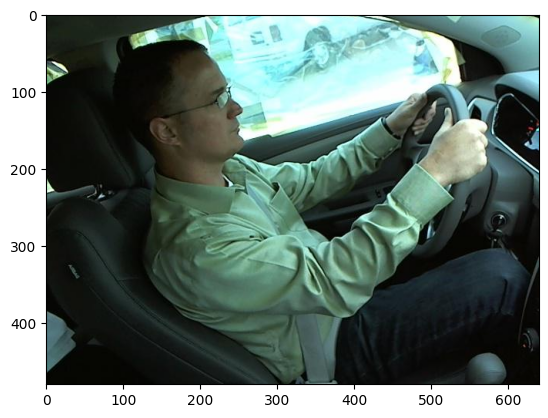

In [6]:
import matplotlib.pyplot as plt

#image_load test
image_path = os.path.join(project_path, 'data/raw/c0_safe_driving/img_231.jpg')
image = preprocess.load_image(image_path)
plt.imshow(image)
plt.show()

In [7]:
def show_batch(images, labels=None, class_names=None, max_images=12):
    images = images[:max_images]
    batch_size = images.size(0)

    cols = 3
    rows = math.ceil(batch_size / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i in range(batch_size):
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].axis("off")

        if labels is not None:
            if class_names:
                axes[i].set_title(class_names[labels[i].item()])
            else:
                axes[i].set_title(f"Label: {labels[i].item()}")

    # empty classes are hidden
    for i in range(batch_size, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))

images = preprocess.denormalize_tensor(images)

show_batch(images, labels)

Output hidden; open in https://colab.research.google.com to view.

In [8]:
# Batch statistics
print("\n" + "="*50)
print("\nBatch Statistics Analysis")
print("="*50)
print(f"\nBatch Statistics:")
print(f"- Batch size: {images.shape[0]}")
print(f"- Image shape: {images.shape[1:]} (C, H, W)")
print(f"- Label range: [{labels.min().item()}, {labels.max().item()}]")

# Check for class imbalance
unique_labels, counts = torch.unique(labels, return_counts=True)
print(f"\nClass distribution in this batch:")
for label, count in zip(unique_labels, counts):
    print(f"  Class {label.item()}: {count} images ({count/images.shape[0]*100:.1f}%)")



Batch Statistics Analysis

Batch Statistics:
- Batch size: 32
- Image shape: torch.Size([3, 224, 224]) (C, H, W)
- Label range: [0, 9]

Class distribution in this batch:
  Class 0: 5 images (15.6%)
  Class 1: 4 images (12.5%)
  Class 2: 1 images (3.1%)
  Class 3: 6 images (18.8%)
  Class 4: 3 images (9.4%)
  Class 5: 1 images (3.1%)
  Class 6: 4 images (12.5%)
  Class 7: 5 images (15.6%)
  Class 8: 2 images (6.2%)
  Class 9: 1 images (3.1%)


In [9]:
print("\n" + "="*50)
print("DATA PIPELINE VALIDATION")
print("="*50)

# Test multiple batches to ensure consistency
print("\nTesting multiple batches...")
num_batches_to_test = 3
all_labels = []

for i, (batch_images, batch_labels) in enumerate(train_loader):
    if i >= num_batches_to_test:
        break

    print(f"\nBatch {i+1}:")
    print(f"  Shape: {batch_images.shape}")
    print(f"  Mean: {batch_images.mean():.4f}, Std: {batch_images.std():.4f}")
    print(f"  Min: {batch_images.min():.4f}, Max: {batch_images.max():.4f}")
    print(f"  Labels: {batch_labels.unique().tolist()}")

    all_labels.extend(batch_labels.tolist())

# Check overall label distribution
print(f"\nOverall label distribution (first {num_batches_to_test} batches):")
unique, counts = np.unique(all_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} images")


DATA PIPELINE VALIDATION

Testing multiple batches...

Batch 1:
  Shape: torch.Size([32, 3, 224, 224])
  Mean: -0.5057, Std: 1.3623
  Min: -2.1179, Max: 2.6400
  Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Batch 2:
  Shape: torch.Size([32, 3, 224, 224])
  Mean: -0.5118, Std: 1.3159
  Min: -2.1179, Max: 2.6400
  Labels: [0, 1, 2, 3, 4, 5, 6, 8, 9]

Batch 3:
  Shape: torch.Size([32, 3, 224, 224])
  Mean: -0.4707, Std: 1.3762
  Min: -2.1179, Max: 2.6400
  Labels: [0, 2, 3, 4, 5, 6, 7, 8, 9]

Overall label distribution (first 3 batches):
  Class 0: 10 images
  Class 1: 8 images
  Class 2: 13 images
  Class 3: 13 images
  Class 4: 10 images
  Class 5: 8 images
  Class 6: 11 images
  Class 7: 9 images
  Class 8: 9 images
  Class 9: 5 images


In [26]:
def plot_class_distribution(loader, class_names=None, max_samples=None, title="Train Class Distribution"):
    """
    Visualise class distribution from loader after data augmentation.
    """

    # Collect all labels from the dataloader
    print("Collecting labels from training dataloader...")
    all_labels = []

    for batch_idx, (images, labels) in enumerate(loader):
        all_labels.extend(labels.numpy().tolist())

        # Limit to reasonable number for analysis
        if max_samples is not None and len(all_labels) > max_samples:
            all_labels = all_labels[:max_samples]
            print(f"  Limited to {max_samples} samples for analysis")
            break

        if (batch_idx + 1) % 100 == 0:
            print(f"  Processed {batch_idx + 1} batches, {len(all_labels)} samples")

    # Calculate statistics
    label_counts = Counter(all_labels)
    total_samples = len(all_labels)
    unique_labels = sorted(label_counts.keys())

    print(f"\n{'='*60}")
    print(f"CLASS DISTRIBUTION ANALYSIS")
    print(f"{'='*60}")
    print(f"Total samples analyzed: {total_samples}")
    print(f"Number of classes: {len(unique_labels)}")

    # Prepare data for visualization
    class_ids = []
    counts = []
    percentages = []

    for class_id in unique_labels:
        count = label_counts[class_id]
        percentage = (count / total_samples) * 100

        class_ids.append(class_id)
        counts.append(count)
        percentages.append(percentage)

        # Get class name
        if class_names and class_id < len(class_names):
            name = class_names[class_id]
        else:
            name = f"Class {class_id}"

        print(f"  {name}: {count} samples ({percentage:.1f}%)")

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(t=title, fontsize=16, fontweight='bold', y=1.05)

    # Plot 1: Bar chart
    colors = plt.cm.Set3(np.arange(len(class_ids)) / len(class_ids))
    bars = axes[0].bar(class_ids, counts, color=colors, edgecolor='black', alpha=0.8)

    axes[0].set_xlabel('Class ID', fontsize=12)
    axes[0].set_ylabel('Number of Samples', fontsize=12)
    axes[0].set_title('Class Distribution (Bar Chart)', fontsize=14)
    axes[0].grid(True, alpha=0.3, axis='y')

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                     f'{count}', ha='center', va='bottom', fontsize=9)

    # Set x-ticks with class names if available
    if class_names and len(class_names) >= len(class_ids):
        tick_labels = []
        for class_id in class_ids:
            name = class_names[class_id]
            if len(name) > 12:
                name = name[:10] + "..."
            tick_labels.append(f"{class_id}\n{name}")
    else:
        tick_labels = [f"Class {cid}" for cid in class_ids]

    axes[0].set_xticks(class_ids)
    axes[0].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    # Plot 2: Pie chart
    pie_labels = []
    for i, (class_id, perc) in enumerate(zip(class_ids, percentages)):
        if perc > 3:  # Show label if > 3%
            if class_names and class_id < len(class_names):
                name = class_names[class_id]
                if len(name) > 10:
                    name = name[:8] + "..."
                pie_labels.append(f"{name}\n{perc:.1f}%")
            else:
                pie_labels.append(f"Class {class_id}\n{perc:.1f}%")
        else:
            pie_labels.append('')

    wedges, texts, autotexts = axes[1].pie(counts, labels=pie_labels, colors=colors,
                                           autopct='', startangle=90,
                                           textprops={'fontsize': 9})
    axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14)
    axes[1].axis('equal')

    # Add imbalance metrics
    max_count = max(counts)
    min_count = min(counts)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    plt.tight_layout()
    plt.show()

    return {
        'class_ids': class_ids,
        'counts': counts,
        'percentages': percentages,
        'total_samples': total_samples
    }


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Processed 100 batches, 3200 samples
  Processed 200 batches, 6400 samples
  Processed 300 batches, 9600 samples
  Processed 400 batches, 12800 samples
  Processed 500 batches, 16000 samples

CLASS DISTRIBUTION ANALYSIS
Total samples analyzed: 17939
Number of classes: 10
  safe_driving: 1991 samples (11.1%)
  texting_right: 1814 samples (10.1%)
  talking_phone_right: 1853 samples (10.3%)
  texting_left: 1877 samples (10.5%)
  talking_phone_left: 1861 samples (10.4%)
  operating_radio: 1849 samples (10.3%)
  drinking: 1860 samples (10.4%)
  reaching_behind: 1602 samples (8.9%)
  hair_makeup: 1529 samples (8.5%)
  talking_passenger: 1703 samples (9.5%)


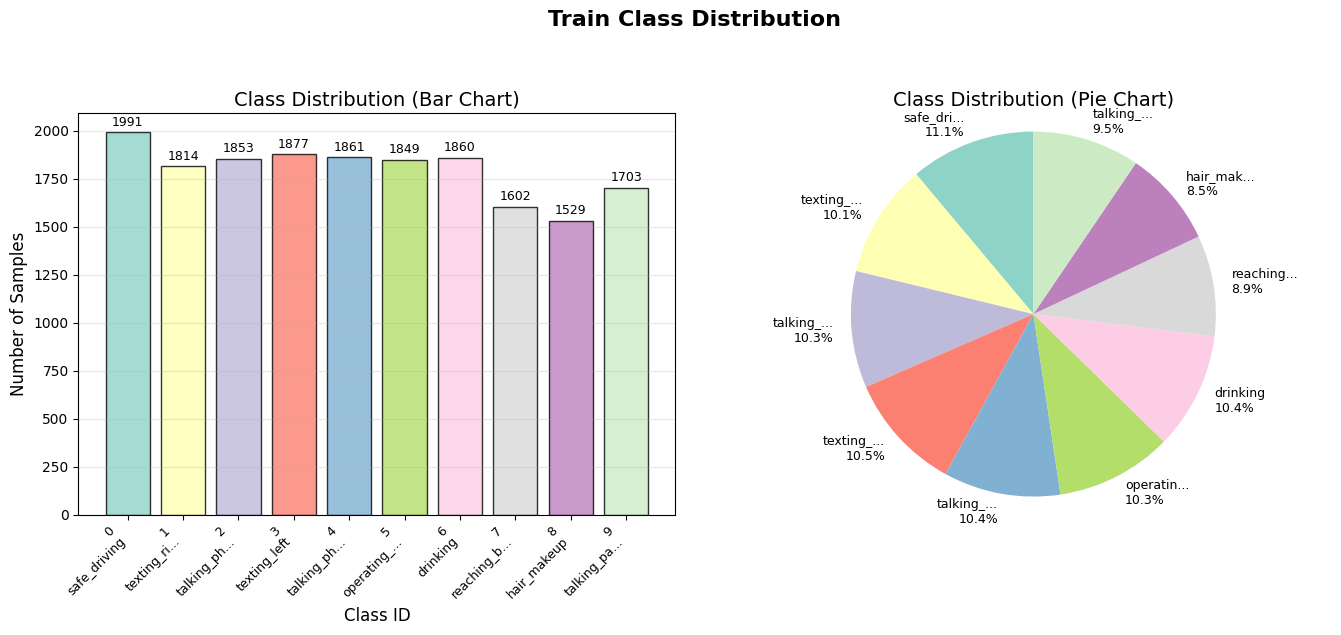


DISTRIBUTION SUMMARY TABLE
 Class_ID          Class_Name  Count  Percentage Percentage_Str
        0        safe_driving   1991   11.098723          11.1%
        1       texting_right   1814   10.112046          10.1%
        2 talking_phone_right   1853   10.329450          10.3%
        3        texting_left   1877   10.463237          10.5%
        4  talking_phone_left   1861   10.374045          10.4%
        5     operating_radio   1849   10.307152          10.3%
        6            drinking   1860   10.368471          10.4%
        7     reaching_behind   1602    8.930264           8.9%
        8         hair_makeup   1529    8.523329           8.5%
        9   talking_passenger   1703    9.493283           9.5%


In [27]:
# Train classes distribution
class_names = [
    "safe_driving", "texting_right", "talking_phone_right", "texting_left",
    "talking_phone_left", "operating_radio", "drinking", "reaching_behind",
    "hair_makeup", "talking_passenger"
]

distribution_info = plot_class_distribution(loader=train_loader, class_names=class_names)
# Summary
df_distribution = pd.DataFrame({
    'Class_ID': distribution_info['class_ids'],
    'Class_Name': [class_names[i] for i in distribution_info['class_ids']],
    'Count': distribution_info['counts'],
    'Percentage': distribution_info['percentages'],
    'Percentage_Str': [f"{p:.1f}%" for p in distribution_info['percentages']]
})

print(f"\n{'='*60}")
print(f"DISTRIBUTION SUMMARY TABLE")
print(f"{'='*60}")
print(df_distribution.to_string(index=False))

In [28]:
# Class distribuation(val, test)

class_names = [
    "safe_driving", "texting_right", "talking_phone_right", "texting_left",
    "talking_phone_left", "operating_radio", "drinking", "reaching_behind",
    "hair_makeup", "talking_passenger"
]

val_file = os.path.join(project_path, 'data/annotations/val_labels.csv')
test_file = os.path.join(project_path, 'data/annotations/test_labels.csv')

# validation & test loaders
val_transform = preprocess.get_val_transforms(input_size=(224,224))
test_transform = preprocess.get_test_transforms(input_size=(224,224))

val_loader = preprocess.create_dataloader(
    csv_file=val_file, images_dir=images_dir,
    transform=val_transform,
    batch_size=batch_size,shuffle=True,
    num_workers=num_workers)

test_loader = preprocess.create_dataloader(
    csv_file=test_file, images_dir=images_dir,
    transform=test_transform,
    batch_size=batch_size,shuffle=True,
    num_workers=num_workers)


VALIDATION CLASS DISTRIBUTION ANALYSIS


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



CLASS DISTRIBUTION ANALYSIS
Total samples analyzed: 2242
Number of classes: 10
  safe_driving: 249 samples (11.1%)
  texting_right: 227 samples (10.1%)
  talking_phone_right: 232 samples (10.3%)
  texting_left: 234 samples (10.4%)
  talking_phone_left: 232 samples (10.3%)
  operating_radio: 232 samples (10.3%)
  drinking: 232 samples (10.3%)
  reaching_behind: 200 samples (8.9%)
  hair_makeup: 191 samples (8.5%)
  talking_passenger: 213 samples (9.5%)


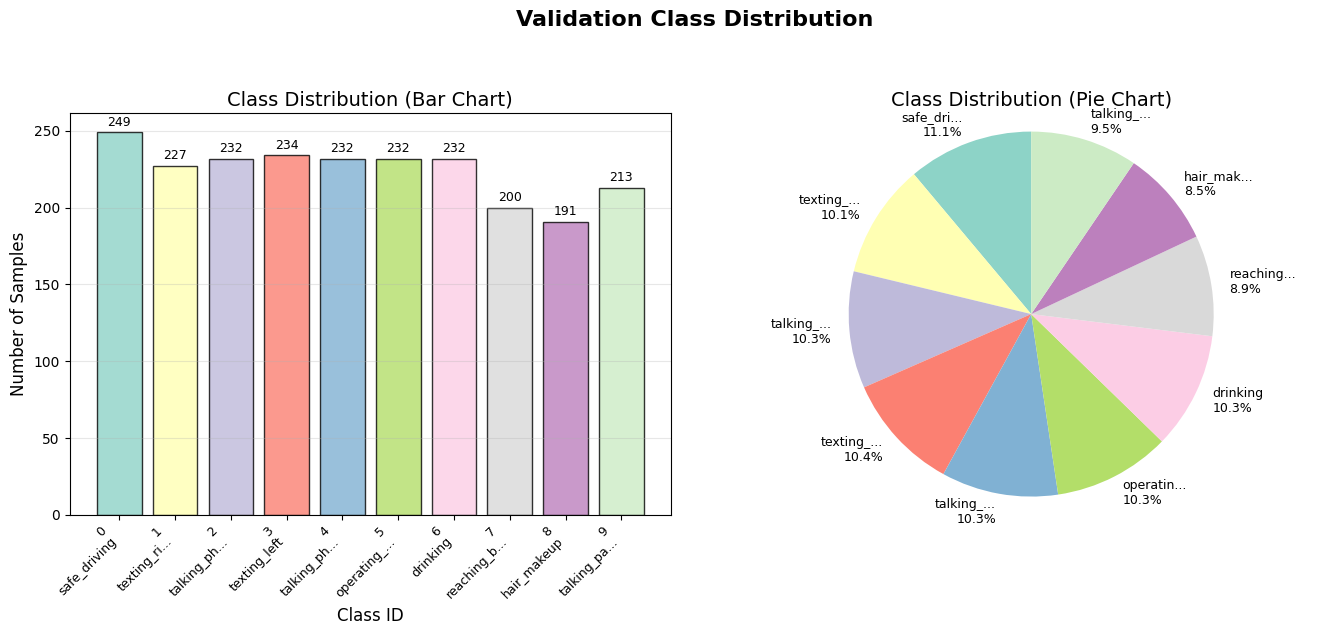

{'class_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'counts': [249, 227, 232, 234, 232, 232, 232, 200, 191, 213],
 'percentages': [11.10615521855486,
  10.124888492417485,
  10.347903657448706,
  10.437109723461194,
  10.347903657448706,
  10.347903657448706,
  10.347903657448706,
  8.920606601248885,
  8.519179304192685,
  9.500446030330062],
 'total_samples': 2242}

In [29]:
#Validation dataset analysis
print(f"\n{'='*60}")
print(f"VALIDATION CLASS DISTRIBUTION ANALYSIS")
print(f"{'='*60}")
plot_class_distribution(loader=val_loader, class_names=class_names,max_samples=None,title="Validation Class Distribution")


TEST CLASS DISTRIBUTION ANALYSIS


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



CLASS DISTRIBUTION ANALYSIS
Total samples analyzed: 2243
Number of classes: 10
  safe_driving: 249 samples (11.1%)
  texting_right: 226 samples (10.1%)
  talking_phone_right: 232 samples (10.3%)
  texting_left: 235 samples (10.5%)
  talking_phone_left: 233 samples (10.4%)
  operating_radio: 231 samples (10.3%)
  drinking: 233 samples (10.4%)
  reaching_behind: 200 samples (8.9%)
  hair_makeup: 191 samples (8.5%)
  talking_passenger: 213 samples (9.5%)


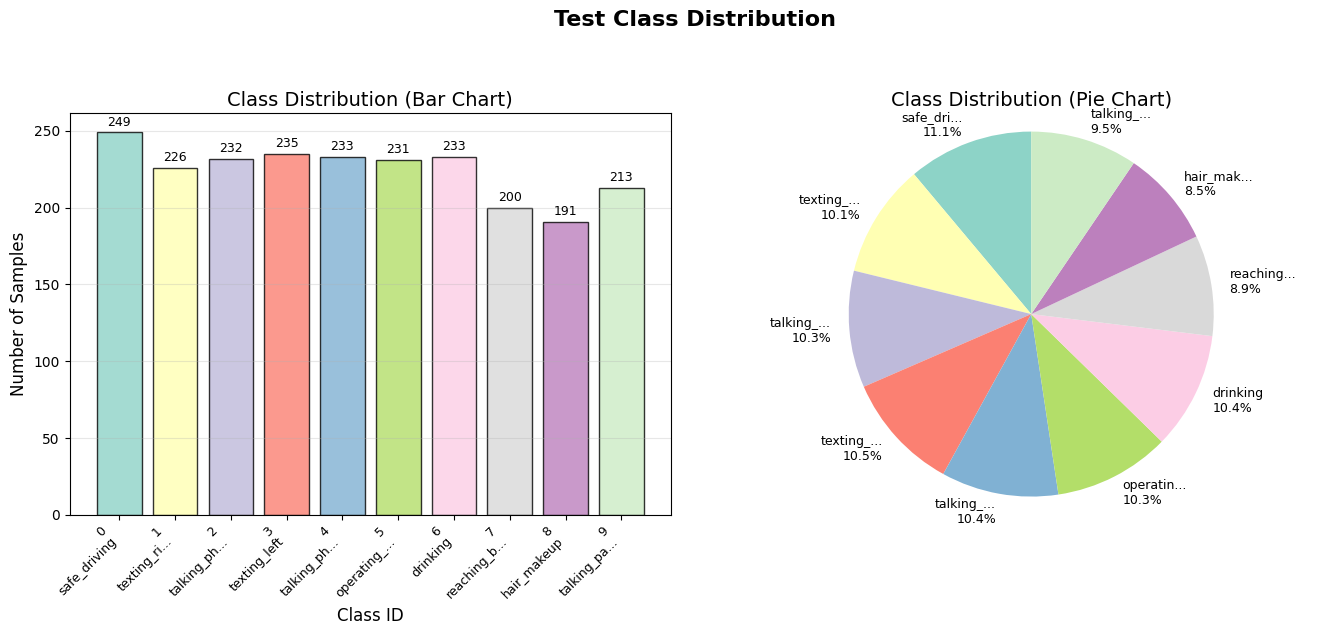

{'class_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'counts': [249, 226, 232, 235, 233, 231, 233, 200, 191, 213],
 'percentages': [11.101203744984396,
  10.075791350869371,
  10.343290236290683,
  10.477039679001338,
  10.3878733838609,
  10.298707088720464,
  10.3878733838609,
  8.916629514043692,
  8.515381185911727,
  9.49621043245653],
 'total_samples': 2243}

In [30]:
#Test dataset analysis
print(f"\n{'='*60}")
print(f"TEST CLASS DISTRIBUTION ANALYSIS")
print(f"{'='*60}")
plot_class_distribution(loader=test_loader, class_names=class_names, max_samples=None,title="Test Class Distribution")

In [20]:
#Normalization check
def check_normalization(dataloader, num_batches=5):
    """
    Check min, max, mean, std of images after normalization.
    """
    print("Checking normalization statistics...\n")

    all_mins = []
    all_maxs = []
    all_means = []
    all_stds = []

    for batch_idx, (images, _) in enumerate(dataloader):
        # images shape: (B, C, H, W)
        all_mins.append(images.min().item())
        all_maxs.append(images.max().item())
        all_means.append(images.mean().item())
        all_stds.append(images.std().item())

        if batch_idx + 1 >= num_batches:
            break

    print(f"Analyzed {num_batches} batches\n")
    print(f"Min value   : {min(all_mins):.3f}")
    print(f"Max value   : {max(all_maxs):.3f}")
    print(f"Mean value  : {sum(all_means)/len(all_means):.3f}")
    print(f"Std value   : {sum(all_stds)/len(all_stds):.3f}")

    print("\nExpected range after normalization: approx [-2, 2]")

    if min(all_mins) < -3 or max(all_maxs) > 3:
        print("Warning: values seem out of expected range")
    else:
        print("Normalization is correct")

#Application on train Dataset
check_normalization(train_loader)


Checking normalization statistics...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Analyzed 5 batches

Min value   : -2.118
Max value   : 2.640
Mean value  : -0.499
Std value   : 1.386

Expected range after normalization: approx [-2, 2]
Normalization is correct
